In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Carico i dati da un file csv con il nome "Tabella_Pv.csv" in C:\Users\vinsc\Documents\Progetti
Tabella_Pv = pd.read_csv(r"C:\Users\vinsc\Documents\DigitalTwin--PowerGrid\Tabella_Pv.csv", index_col=0)
# Carico i dati da un file csv con il nome "Tabella_Load.csv" in C:\Users\vinsc\Documents\Progetti
Tabella_Load= pd.read_csv(r"C:\Users\vinsc\Documents\DigitalTwin--PowerGrid\Tabella_Load.csv", index_col=0)

In [2]:
#Cambio nome alla colonna Time in DateTime
Tabella_Load = Tabella_Load.rename(columns={"Time": "DateTime"})
print(Tabella_Load.head())

              DateTime    House1    House2    House3    House4    House5  \
0  2023-09-18 00:00:00  0.353926  0.084078  0.303328  0.252427  0.386085   
1  2023-09-18 01:00:00  0.526320  0.057124  0.283109  0.226029  0.441071   
2  2023-09-18 02:00:00  0.536236  0.081743  0.280368  0.218727  0.484487   
3  2023-09-18 03:00:00  0.539307  0.085029  0.270917  0.206596  0.433297   
4  2023-09-18 04:00:00  0.553143  0.058800  0.265627  0.209230  0.420699   

    House11  Total_Load  
0  0.209238    1.769925  
1  0.176473    1.904744  
2  0.141122    1.941006  
3  0.121543    1.845225  
4  0.135342    1.829802  


In [3]:
print(Tabella_Pv.head())

              DateTime  Day_of_Year Day_Name Month_Name Season  Year        Pv
0  2025-11-30 21:00:00          334   Sunday   November   Fall  2025  0.872632
1  2025-11-30 18:00:00          334   Sunday   November   Fall  2025  0.631878
2  2025-11-30 16:00:00          334   Sunday   November   Fall  2025  0.631878
3  2025-11-30 23:00:00          334   Sunday   November   Fall  2025  1.011269
4  2025-11-30 06:00:00          334   Sunday   November   Fall  2025  0.724908


In [4]:
#Unisco le due tabelle in una sola tabella chiamata Tabella_Batteria, unendo le righe in base alla colonna DateTime
Tabella_Batteria = pd.merge(Tabella_Load,Tabella_Pv, on="DateTime", how="left")

#Stampo le prime 5 righe della tabella Tabella_Batteria
print(Tabella_Batteria.head())

              DateTime    House1    House2    House3    House4    House5  \
0  2023-09-18 00:00:00  0.353926  0.084078  0.303328  0.252427  0.386085   
1  2023-09-18 01:00:00  0.526320  0.057124  0.283109  0.226029  0.441071   
2  2023-09-18 02:00:00  0.536236  0.081743  0.280368  0.218727  0.484487   
3  2023-09-18 03:00:00  0.539307  0.085029  0.270917  0.206596  0.433297   
4  2023-09-18 04:00:00  0.553143  0.058800  0.265627  0.209230  0.420699   

    House11  Total_Load  Day_of_Year Day_Name Month_Name Season    Year  \
0  0.209238    1.769925        261.0   Monday  September   Fall  2023.0   
1  0.176473    1.904744        261.0   Monday  September   Fall  2023.0   
2  0.141122    1.941006        261.0   Monday  September   Fall  2023.0   
3  0.121543    1.845225        261.0   Monday  September   Fall  2023.0   
4  0.135342    1.829802        261.0   Monday  September   Fall  2023.0   

         Pv  
0  0.903532  
1  0.680293  
2  0.869988  
3  1.005981  
4  1.057536  


In [5]:
#Controllo che non ci siano righe ripetute o valori NaN in tutte le colonne della tabella Tabella_Batteria
print(Tabella_Batteria.duplicated().sum())
print(Tabella_Batteria.isna().sum())

#Stampo le righe con i valori NaN
print(Tabella_Batteria[Tabella_Batteria.isna().any(axis=1)])

#Per le righe con valori NaN, calcolo Day_of_Year, Day_Name, Month_Name, Season e Year
Tabella_Batteria["DateTime"] = pd.to_datetime(Tabella_Batteria["DateTime"])
Tabella_Batteria["Day_of_Year"] = Tabella_Batteria["DateTime"].dt.dayofyear
Tabella_Batteria["Day_Name"] = Tabella_Batteria["DateTime"].dt.day_name()
Tabella_Batteria["Month_Name"] = Tabella_Batteria["DateTime"].dt.month_name()
Tabella_Batteria["Season"] = Tabella_Batteria["DateTime"].dt.month%12 // 3 + 1
Tabella_Batteria["Year"] = Tabella_Batteria["DateTime"].dt.year

#Nella colonna Pv, sostituisco i valori NaN con il 40% del valore della colonna Total_Load
Tabella_Batteria["Pv"] = Tabella_Batteria["Pv"].fillna(Tabella_Batteria["Total_Load"] * 0.4)

#Stampo le righe con i valori NaN
print(Tabella_Batteria[Tabella_Batteria.isna().any(axis=1)])

#Controllo che non ci siano valori NaN in tutte le colonne della tabella Tabella_Batteria
print(Tabella_Batteria.isna().sum())

0
DateTime       0
House1         0
House2         0
House3         0
House4         0
House5         0
House11        0
Total_Load     0
Day_of_Year    2
Day_Name       2
Month_Name     2
Season         2
Year           2
Pv             2
dtype: int64
                  DateTime    House1    House2    House3    House4    House5  \
4659   2024-03-31 02:00:00  1.039407  0.108926  0.167893  0.218727  0.443696   
13396  2025-03-30 02:00:00  1.187916  0.107935  0.219117  0.204371  0.338181   

        House11  Total_Load  Day_of_Year Day_Name Month_Name Season  Year  Pv  
4659   0.141122    2.361008          NaN      NaN        NaN    NaN   NaN NaN  
13396  0.223808    2.540950          NaN      NaN        NaN    NaN   NaN NaN  
Empty DataFrame
Columns: [DateTime, House1, House2, House3, House4, House5, House11, Total_Load, Day_of_Year, Day_Name, Month_Name, Season, Year, Pv]
Index: []
DateTime       0
House1         0
House2         0
House3         0
House4         0
House5         0
Hous

In [6]:
# Moltiplico i valori della colonna Pv per 2.5 perché rientro in un caso molto più rilevante da osservare,
# altrimenti i valori di Pv sono troppo piccoli rispetto a Total_Load e non servirebbero.
Tabella_Batteria['Pv'] = Tabella_Batteria['Pv'] * 2
print(Tabella_Batteria[['DateTime', 'Pv', 'Total_Load']])

                 DateTime        Pv  Total_Load
0     2023-09-18 00:00:00  1.807064    1.769925
1     2023-09-18 01:00:00  1.360586    1.904744
2     2023-09-18 02:00:00  1.739977    1.941006
3     2023-09-18 03:00:00  2.011962    1.845225
4     2023-09-18 04:00:00  2.115072    1.829802
...                   ...       ...         ...
15837 2025-07-09 19:00:00  1.307379    3.523031
15838 2025-07-09 20:00:00  0.789517    3.223963
15839 2025-07-09 21:00:00  0.668230    2.849018
15840 2025-07-09 22:00:00  0.784890    2.400885
15841 2025-07-09 23:00:00  0.882712    2.769173

[15842 rows x 3 columns]


In [7]:
# Caratteristiche della batteria

E_max = 80.0        # kWh capacità nominale batteria
P_max = 10.0        # kW potenza massima carica/scarica
eta_ch = 0.95       # efficienza di carica
eta_dis = 0.95      # efficienza di scarica

# limiti realistici di utilizzo batteria
SOC_min = 0.10
SOC_max = 0.90

E_min = SOC_min * E_max
E_max_use = SOC_max * E_max

# stato iniziale batteria
soc = 0.50
energy = soc * E_max

In [8]:
# Calcolo i flussi 

Tabella_Batteria['Pv-Bat'] = 0.0
Tabella_Batteria['Pv-#'] = 0.0
Tabella_Batteria['Bat-Load'] = 0.0
Tabella_Batteria['#-Load'] = 0.0
Tabella_Batteria['Et'] = 0.0
Tabella_Batteria['SOC'] = 0.0

# Primo valore di Et = 40 kWh
Tabella_Batteria.at[0, 'Et'] = 40.0

# Implemento le formule di bilancio

pv_bat_list = []
pv_grid_list = []
bat_load_list = []
grid_load_list = []
et_list = []
soc_list = []

for i, row in Tabella_Batteria.iterrows():

    pv = float(row['Pv'])
    load = float(row['Total_Load'])
    
    pv_bat = 0.0
    pv_grid = 0.0
    bat_load = 0.0
    grid_load = 0.0
    et = 0.0
    soc = 0.0

    # Valore precedente di Et
    if i == 0:
        e_pre = 40.0
    else:
        e_pre = et_list[-1]

    # Bilancio Energia
    if pv >= load:
        # Il surplus del PV può andare alla batteria
        pv_bat = pv - load
        
        # limite di potenza di carica
        if pv_bat >= P_max:
            pv_grid = pv_bat - P_max
            pv_bat = P_max

        # Bilancio Batteria Carica
        et = e_pre + eta_ch * pv_bat

    if pv < load:
        # Il deficit viene coperto prima dalla batteria
        bat_load = load - pv
        
        # limite di potenza di scarica
        if bat_load >= P_max:
            grid_load = bat_load - P_max
            bat_load = P_max

        # Bilancio Batteria Scarica
        et = e_pre - (bat_load / eta_dis)
    
    # Stato della Batteria - limite superiore
    if et > E_max_use:
        # quanta potenza posso davvero caricare senza superare E_max
        pv_bat = (E_max_use - e_pre) / eta_ch
        
        # per sicurezza evito valori negativi
        if pv_bat < 0:
            pv_bat = 0.0

        # il resto del surplus va in rete
        pv_grid = (pv - load) - pv_bat
        
        if pv_grid < 0:
            pv_grid = 0.0

        et = E_max_use

    # Stato della Batteria - limite inferiore
    if et < E_min:
        # quanta potenza posso davvero scaricare senza andare sotto E_min
        bat_load = (e_pre - E_min) * eta_dis
        
        if bat_load < 0:
            bat_load = 0.0

        # il resto del deficit viene coperto dalla rete
        grid_load = (load - pv) - bat_load
        
        if grid_load < 0:
            grid_load = 0.0

        et = E_min

    # Calcolo SOC
    soc = et / E_max

    # Salvo i risultati
    pv_bat_list.append(pv_bat)
    pv_grid_list.append(pv_grid)
    bat_load_list.append(bat_load)
    grid_load_list.append(grid_load)
    et_list.append(et)
    soc_list.append(soc)
            
# Aggiungo al dataset i risultati

Tabella_Batteria['Pv-Bat'] = pv_bat_list
Tabella_Batteria['Pv-#'] = pv_grid_list
Tabella_Batteria['Bat-Load'] = bat_load_list
Tabella_Batteria['#-Load'] = grid_load_list
Tabella_Batteria['Et'] = et_list
Tabella_Batteria['SOC'] = soc_list

Tabella_Batteria[['DateTime','Pv', 'Pv-Bat', 'Pv-#', 'Bat-Load', '#-Load', 'Total_Load', 'Et', 'SOC']]

,DateTime,Pv,Pv-Bat,Pv-#,Bat-Load,#-Load,Total_Load,Et,SOC
0,2023-09-18 00:00:00,1.807064,0.037139,0.0,0.000000,0.000000,1.769925,40.035282,0.500441
1,2023-09-18 01:00:00,1.360586,0.000000,0.0,0.544158,0.000000,1.904744,39.462484,0.493281
2,2023-09-18 02:00:00,1.739977,0.000000,0.0,0.201029,0.000000,1.941006,39.250875,0.490636
3,2023-09-18 03:00:00,2.011962,0.166737,0.0,0.000000,0.000000,1.845225,39.409274,0.492616
4,2023-09-18 04:00:00,2.115072,0.285270,0.0,0.000000,0.000000,1.829802,39.680281,0.496004
...,...,...,...,...,...,...,...,...,...
15837,2025-07-09 19:00:00,1.307379,0.000000,0.0,0.000000,2.215652,3.523031,8.000000,0.100000
15838,2025-07-09 20:00:00,0.789517,0.000000,0.0,0.000000,2.434446,3.223963,8.000000,0.100000
15839,2025-07-09 21:00:00,0.668230,0.000000,0.0,0.000000,2.180788,2.849018,8.000000,0.100000
15840,2025-07-09 22:00:00,0.784890,0.000000,0.0,0.000000,1.615995,2.400885,8.000000,0.100000


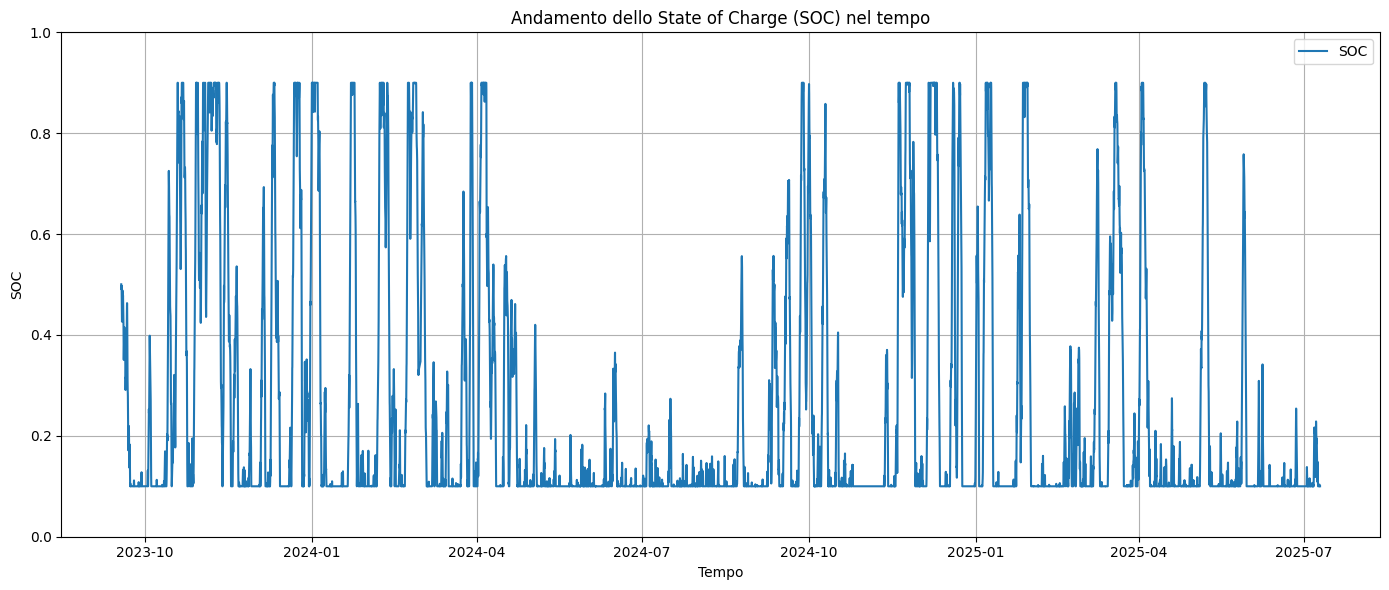

In [9]:
# Grafico SOC

Tabella_Batteria["DateTime"] = pd.to_datetime(Tabella_Batteria["DateTime"], errors="coerce")
Tabella_Batteria = Tabella_Batteria.sort_values("DateTime")

plt.figure(figsize=(14, 6))
plt.plot(Tabella_Batteria["DateTime"], Tabella_Batteria["SOC"], label="SOC")
plt.xlabel("Tempo")
plt.ylabel("SOC")
plt.title("Andamento dello State of Charge (SOC) nel tempo")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

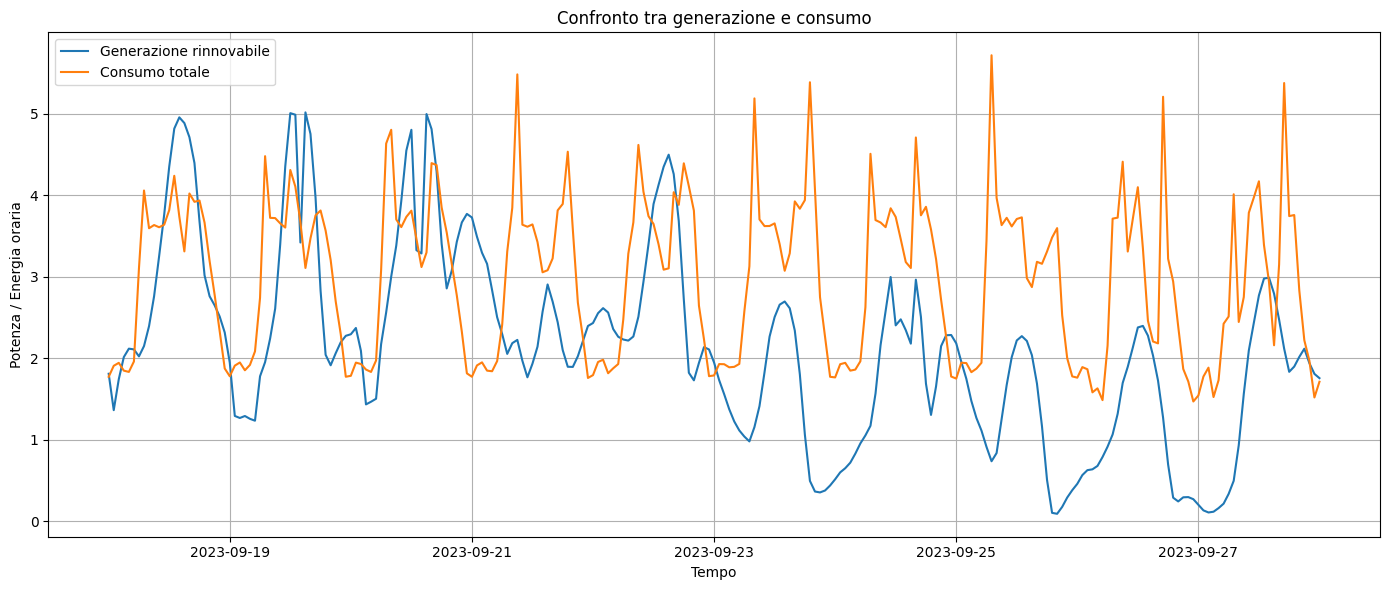

In [14]:
# Grafico Consumo-Generazione

Tabella_Batteria["DateTime"] = pd.to_datetime(Tabella_Batteria["DateTime"], errors="coerce")
Tabella_Batteria = Tabella_Batteria.sort_values("DateTime")
start = Tabella_Batteria["DateTime"].min()
end = start + pd.Timedelta(days=10)

plot_df = Tabella_Batteria[
    (Tabella_Batteria["DateTime"] >= start) &
    (Tabella_Batteria["DateTime"] <= end)
].copy()

plt.figure(figsize=(14, 6))
plt.plot(plot_df["DateTime"], plot_df["Pv"], label="Generazione rinnovabile")
plt.plot(plot_df["DateTime"], plot_df["Total_Load"], label="Consumo totale")
plt.xlabel("Tempo")
plt.ylabel("Potenza / Energia oraria")
plt.title("Confronto tra generazione e consumo")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
DS_Modelli = Tabella_Batteria[['DateTime','Pv', 'Pv-Bat', 'Pv-#', 'Bat-Load', '#-Load', 'Total_Load', 'Et', 'SOC']]
DS_Modelli.to_csv(r"C:\Users\vinsc\Documents\DigitalTwin--PowerGrid\DS_Modelli.csv", index=False)